In [ ]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("phenomsg/waste-classification")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'waste-classification' dataset.
Dataset downloaded to: /kaggle/input/waste-classification


In [ ]:
import os

print(os.listdir(path))

['Organic', 'Non-Recyclable', 'Hazardous', 'Recyclable']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import tensorflow as tf
import numpy as np

# Dataset path
dataset_path = "/kaggle/input/waste-classification"

# Class mapping
# Folder name : Label
classes = {
    "Organic": 0,            # renamed as Biodegradable
    "Recyclable": 1,
    "Non-Recyclable": 2
}

# Display names for model output
class_names = {
    0: "Biodegradable",
    1: "Recyclable",
    2: "Non-Recyclable"
}

# Image extensions
image_extensions = (".jpg", ".jpeg", ".png")


# -------------------------------
# Collect image paths and labels
# -------------------------------

image_paths = []
labels = []

for folder_name, label in classes.items():

    folder_path = os.path.join(dataset_path, folder_name)

    for root, dirs, files in os.walk(folder_path):
        for file in files:

            if file.lower().endswith(image_extensions):

                image_paths.append(
                    os.path.join(root, file)
                )

                labels.append(label)


print("Total images:", len(image_paths))


# Check class distribution
unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(class_names[u], ":", c)


# -------------------------------
# TensorFlow image loader
# -------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Normalize pixel values
    image = image / 255.0

    return image, label



# Create TensorFlow Dataset

dataset = tf.data.Dataset.from_tensor_slices(
    (image_paths, labels)
)


dataset = dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Shuffle
dataset = dataset.shuffle(
    buffer_size=len(image_paths)
)


# Split dataset

total_size = len(image_paths)

train_size = int(0.8 * total_size)

train_ds = dataset.take(train_size)

val_ds = dataset.skip(train_size)


# Batch and optimize

train_ds = (
    train_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# Check output

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Total images: 1952
Biodegradable : 659
Recyclable : 651
Non-Recyclable : 642
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input layer
    layers.Input(shape=(224,224,3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer (3 classes)
    layers.Dense(3, activation="softmax")
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.4158 - loss: 1.1968 - val_accuracy: 0.4246 - val_loss: 1.0371
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 244s 4s/step - accuracy: 0.4728 - loss: 1.0175 - val_accuracy: 0.5396 - val_loss: 0.9763
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 299s 5s/step - accuracy: 0.5022 - loss: 0.9704 - val_accuracy: 0.5754 - val_loss: 0.9060
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/step - accuracy: 0.5509 - loss: 0.9270 - val_accuracy: 0.6292 - val_loss: 0.8443
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - accuracy: 0.5906 - loss: 0.8786 - val_accuracy: 0.6522 - val_loss: 0.7922
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/step - accuracy: 0.6291 - loss: 0.8337 - val_accuracy: 0.7263 - val_loss: 0.6808
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step - accuracy: 0.6688 - loss: 0.7437 - val_accuracy: 0.7749 - val_loss: 0.5884
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.7156 - loss: 0.6482 - val_accuracy: 0.8363 - v

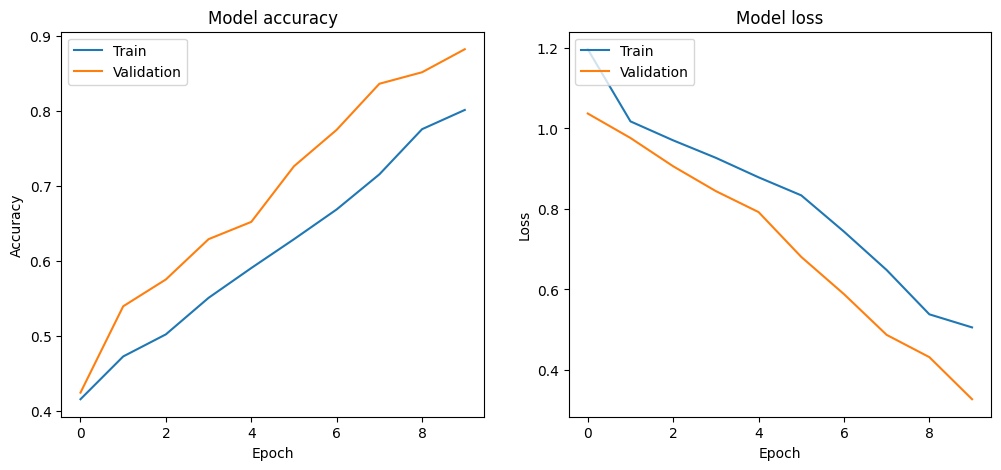

In [ ]:
import matplotlib.pyplot as plt

# Plotting training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 812ms/step - accuracy: 0.8824 - loss: 0.3590
Validation Loss: 0.3590
Validation Accuracy: 0.8824


Let's also visualize some predictions from the validation set to see how the model is performing on individual images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step


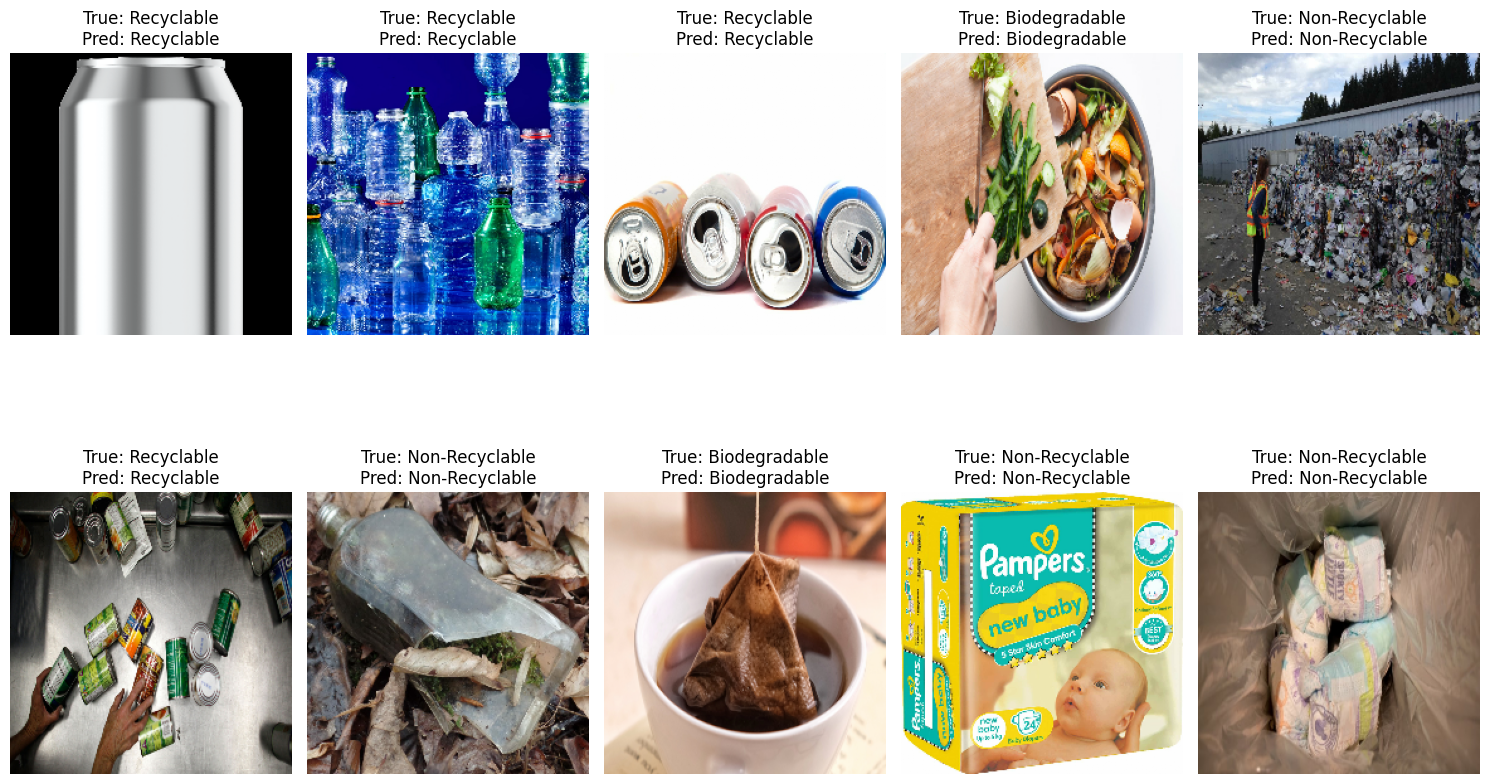

In [ ]:
import numpy as np

def get_predictions_and_labels(dataset, model, num_samples=5):
    true_labels = []
    predictions = []
    images = []
    sample_count = 0

    for img_batch, label_batch in dataset:
        preds = model.predict(img_batch)
        predicted_labels = np.argmax(preds, axis=1)

        for i in range(len(img_batch.numpy())):
            if sample_count < num_samples:
                images.append(img_batch.numpy()[i])
                true_labels.append(label_batch.numpy()[i])
                predictions.append(predicted_labels[i])
                sample_count += 1
            else:
                break
        if sample_count >= num_samples:
            break
    return np.array(images), np.array(true_labels), np.array(predictions)

# Get a few sample predictions
sample_images, sample_true_labels, sample_predictions = get_predictions_and_labels(val_ds, model, num_samples=10)

# Map numerical labels to class names for display
display_true_labels = [class_names[label] for label in sample_true_labels]
display_predictions = [class_names[pred] for pred in sample_predictions]

# Plotting the sample images with their true and predicted labels
plt.figure(figsize=(15, 10))
for i in range(len(sample_images)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"True: {display_true_labels[i]}\nPred: {display_predictions[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()